# Spike Frequency Analysis Pipeline

This notebook provides a reproducible Python workflow for detecting spontaneous action potentials and calculating spike frequency from current-clamp electrophysiological recordings exported from HEKA/PatchMaster ASCII files.

The pipeline includes:

- HEKA ASCII file import
- action potential peak detection
- spike count calculation
- spike frequency calculation in Hz
- batch analysis of recordings
- export of analysis results tables
- representative quality-control visualization

Recording names and experimental conditions are anonymized in this public version to protect unpublished experimental details.

## Workflow Overview

1. Import libraries  
2. User settings  
3. HEKA ASCII loader  
4. Spike detection algorithm  
5. Batch spike-frequency analysis  
6. Export results  
7. Quality-control analysis  
8. Representative quality-control visualization  


In [1]:
# ========================================
# MASTER SETUP CELL
# Run this first
# ========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

print("Setup complete")

Mounted at /content/drive
Setup complete


In [2]:
# ============================================================
# USER SETTINGS
# ============================================================

# Path containing HEKA/PatchMaster ASCII files
BASE_PATH = "/content/drive/MyDrive/PatchClampData/Python2/"

# Recordings included in the public workflow
# These names are anonymized for GitHub.
# In a real analysis, replace these with the names of your exported .asc files.
FILE_LIST = [
    "recording_01.asc",
    "recording_02.asc",
    "recording_03.asc"
]

# Generic group name used in exported tables
CONDITION_NAME = "Example_Group"

# Analysis window
START_TIME_S = 0.3
END_TIME_S = 60

# Spike-detection parameters
MIN_PEAK_MV = 0
MIN_PROMINENCE_MV = 20
REFRACTORY_PERIOD_S = 0.05

# Plot settings
Y_MIN = -90
Y_MAX = 50

# Output file names
SUMMARY_CSV_NAME = "spike_frequency_summary.csv"
SPIKE_TABLE_CSV_NAME = "spike_by_spike_table.csv"
GRAPHPAD_CSV_NAME = "graphpad_spike_frequency_Hz.csv"

print("User settings loaded")

User settings loaded


In [3]:
# ============================================================
# HEKA PATCHMASTER ASCII FILE IMPORT
# ============================================================

def load_heka_ascii_voltage(file_path):
    """
    Load a HEKA/PatchMaster ASCII file exported from current-clamp recordings.

    Expected columns include:
    - Index
    - Time[s]
    - V-mon[V]
    - Stimulus

    Returns
    -------
    data : pandas.DataFrame
        DataFrame containing:
        - Time_s
        - Voltage_mV
    """

    header_line = None

    with open(file_path, "r") as f:
        for line_number, line in enumerate(f):
            if line.strip().startswith('"Index"') or line.strip().startswith("Index"):
                header_line = line_number
                break

    if header_line is None:
        raise ValueError(f"HEKA header not found: {file_path}")

    data = pd.read_csv(
        file_path,
        sep=",",
        skiprows=header_line
    )

    data.columns = (
        data.columns
        .str.strip()
        .str.replace('"', "", regex=False)
    )

    time_col = next(col for col in data.columns if "Time[s]" in col)
    voltage_col = next(col for col in data.columns if "V-mon[V]" in col)

    data = data[[time_col, voltage_col]].copy()
    data.columns = ["Time_s", "Voltage_V"]

    data["Time_s"] = pd.to_numeric(data["Time_s"], errors="coerce")
    data["Voltage_V"] = pd.to_numeric(data["Voltage_V"], errors="coerce")

    data = data.dropna()

    # Convert voltage from V to mV
    data["Voltage_mV"] = data["Voltage_V"] * 1000

    return data[["Time_s", "Voltage_mV"]]

print("HEKA ASCII loader ready")

HEKA ASCII loader ready


In [4]:
# ============================================================
# SPIKE DETECTION ALGORITHM
# ============================================================

def analyze_spike_frequency(
    file_path,
    recording_name,
    condition_name=CONDITION_NAME,
    start_time_s=START_TIME_S,
    end_time_s=END_TIME_S,
    min_peak_mV=MIN_PEAK_MV,
    min_prominence_mV=MIN_PROMINENCE_MV,
    refractory_period_s=REFRACTORY_PERIOD_S,
    y_min=Y_MIN,
    y_max=Y_MAX,
    save_figure=False
):
    """
    Detect spontaneous action potentials and calculate spike frequency.

    Analysis workflow
    -----------------
    1. Import HEKA/PatchMaster ASCII recording
    2. Select analysis window
    3. Detect action potential peaks using amplitude, prominence, and refractory period
    4. Calculate:
        - spike count
        - recording duration
        - spike frequency in Hz
    5. Generate a quality-control plot showing detected spikes

    Returns
    -------
    results : dict
        Summary of spike-frequency analysis.

    spike_table : pandas.DataFrame
        Spike-by-spike table containing spike number, spike time, and spike peak.
    """

    data = load_heka_ascii_voltage(file_path)

    analysis_data = data[
        (data["Time_s"] >= start_time_s) &
        (data["Time_s"] <= end_time_s)
    ].copy()

    time = analysis_data["Time_s"].values
    voltage = analysis_data["Voltage_mV"].values

    if len(time) < 10:
        raise ValueError("Selected analysis window is too short or empty.")

    dt = np.median(np.diff(time))
    sampling_rate_Hz = 1 / dt
    min_distance_points = int(refractory_period_s / dt)

    peaks, properties = find_peaks(
        voltage,
        height=min_peak_mV,
        prominence=min_prominence_mV,
        distance=min_distance_points
    )

    spike_times = time[peaks]
    spike_peaks_mV = voltage[peaks]

    spike_count = len(peaks)
    duration_s = time[-1] - time[0]
    spike_frequency_Hz = spike_count / duration_s

    results = {
        "recording_name": recording_name,
        "condition": condition_name,
        "spike_count": spike_count,
        "duration_s": duration_s,
        "spike_frequency_Hz": spike_frequency_Hz,
        "sampling_rate_Hz": sampling_rate_Hz,
        "min_peak_mV": min_peak_mV,
        "min_prominence_mV": min_prominence_mV,
        "refractory_period_s": refractory_period_s
    }

    spike_table = pd.DataFrame({
        "recording_name": recording_name,
        "spike_number": np.arange(1, spike_count + 1),
        "spike_time_s": spike_times,
        "spike_peak_mV": spike_peaks_mV
    })

    # Quality-control plot
    plt.figure(figsize=(15, 5), dpi=300)

    plt.plot(
        time,
        voltage,
        color="black",
        linewidth=0.8
    )

    plt.scatter(
        spike_times,
        spike_peaks_mV,
        color="red",
        s=25,
        label="Detected spikes"
    )

    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Membrane Potential (mV)", fontsize=14)
    plt.title(f"{recording_name} - Spike Detection", fontsize=14)

    plt.xlim(start_time_s, end_time_s)
    plt.ylim(y_min, y_max)
    plt.legend(frameon=False)
    plt.tight_layout()

    if save_figure:
        plt.savefig(
            f"{recording_name}_spike_detection.png",
            dpi=600,
            bbox_inches="tight"
        )

        plt.savefig(
            f"{recording_name}_spike_detection.svg",
            format="svg",
            bbox_inches="tight"
        )

    plt.show()

    return results, spike_table

print("Spike detection algorithm ready")

Spike detection algorithm ready


In [5]:
# ============================================================
# BATCH SPIKE-FREQUENCY ANALYSIS
# ============================================================

results = []
all_spike_tables = []

for index, file_name in enumerate(FILE_LIST, start=1):

    file_path = os.path.join(BASE_PATH, file_name)

    # Public anonymized recording name
    recording_name = f"recording_{index:02d}"

    print("\n----------------------------------------")
    print(f"Analyzing: {recording_name}")
    print(f"Input file: {file_name}")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    out, spike_table = analyze_spike_frequency(
        file_path=file_path,
        recording_name=recording_name,
        condition_name=CONDITION_NAME,
        start_time_s=START_TIME_S,
        end_time_s=END_TIME_S,
        min_peak_mV=MIN_PEAK_MV,
        min_prominence_mV=MIN_PROMINENCE_MV,
        refractory_period_s=REFRACTORY_PERIOD_S,
        y_min=Y_MIN,
        y_max=Y_MAX,
        save_figure=False
    )

    results.append(out)
    all_spike_tables.append(spike_table)

# Create summary table
results_df = pd.DataFrame(results)

if len(results_df) > 0:
    results_df["duration_s"] = results_df["duration_s"].round(2)
    results_df["spike_frequency_Hz"] = results_df["spike_frequency_Hz"].round(3)
    results_df["sampling_rate_Hz"] = results_df["sampling_rate_Hz"].round(1)

display(results_df)


----------------------------------------
Analyzing: recording_01
Input file: recording_01.asc
File not found: /content/drive/MyDrive/PatchClampData/Python2/recording_01.asc

----------------------------------------
Analyzing: recording_02
Input file: recording_02.asc
File not found: /content/drive/MyDrive/PatchClampData/Python2/recording_02.asc

----------------------------------------
Analyzing: recording_03
Input file: recording_03.asc
File not found: /content/drive/MyDrive/PatchClampData/Python2/recording_03.asc


""


In [6]:
# ============================================================
# EXPORT ANALYSIS RESULTS
# ============================================================

if len(results_df) > 0:

    # Save spike-frequency summary table
    summary_output_path = os.path.join(BASE_PATH, SUMMARY_CSV_NAME)
    results_df.to_csv(summary_output_path, index=False)

    print(f"Spike-frequency summary saved to: {summary_output_path}")

    # Save complete spike-by-spike table
    if len(all_spike_tables) > 0:

        spike_by_spike_df = pd.concat(all_spike_tables, ignore_index=True)

        spike_by_spike_df["spike_time_s"] = spike_by_spike_df["spike_time_s"].round(4)
        spike_by_spike_df["spike_peak_mV"] = spike_by_spike_df["spike_peak_mV"].round(2)

        spike_table_output_path = os.path.join(BASE_PATH, SPIKE_TABLE_CSV_NAME)
        spike_by_spike_df.to_csv(spike_table_output_path, index=False)

        print(f"Spike-by-spike table saved to: {spike_table_output_path}")

    # Save GraphPad-friendly table
    graphpad_df = results_df[["spike_frequency_Hz"]].copy()
    graphpad_df.columns = [CONDITION_NAME]

    graphpad_output_path = os.path.join(BASE_PATH, GRAPHPAD_CSV_NAME)
    graphpad_df.to_csv(graphpad_output_path, index=False)

    print(f"GraphPad-friendly table saved to: {graphpad_output_path}")

else:
    print("No batch results to export. This is expected if anonymized example files are not present.")

No batch results to export. This is expected if anonymized example files are not present.


## Quality-Control Analysis

A representative current-clamp recording was visualized together with the detected action potential peaks.

Detected spikes are shown as red markers. Spike frequency is calculated as the number of detected spikes divided by the analyzed recording duration.

This quality-control visualization allows visual confirmation that the automated peak-detection parameters correctly identify action potentials while minimizing false detections.

Recording names are anonymized in the displayed output.

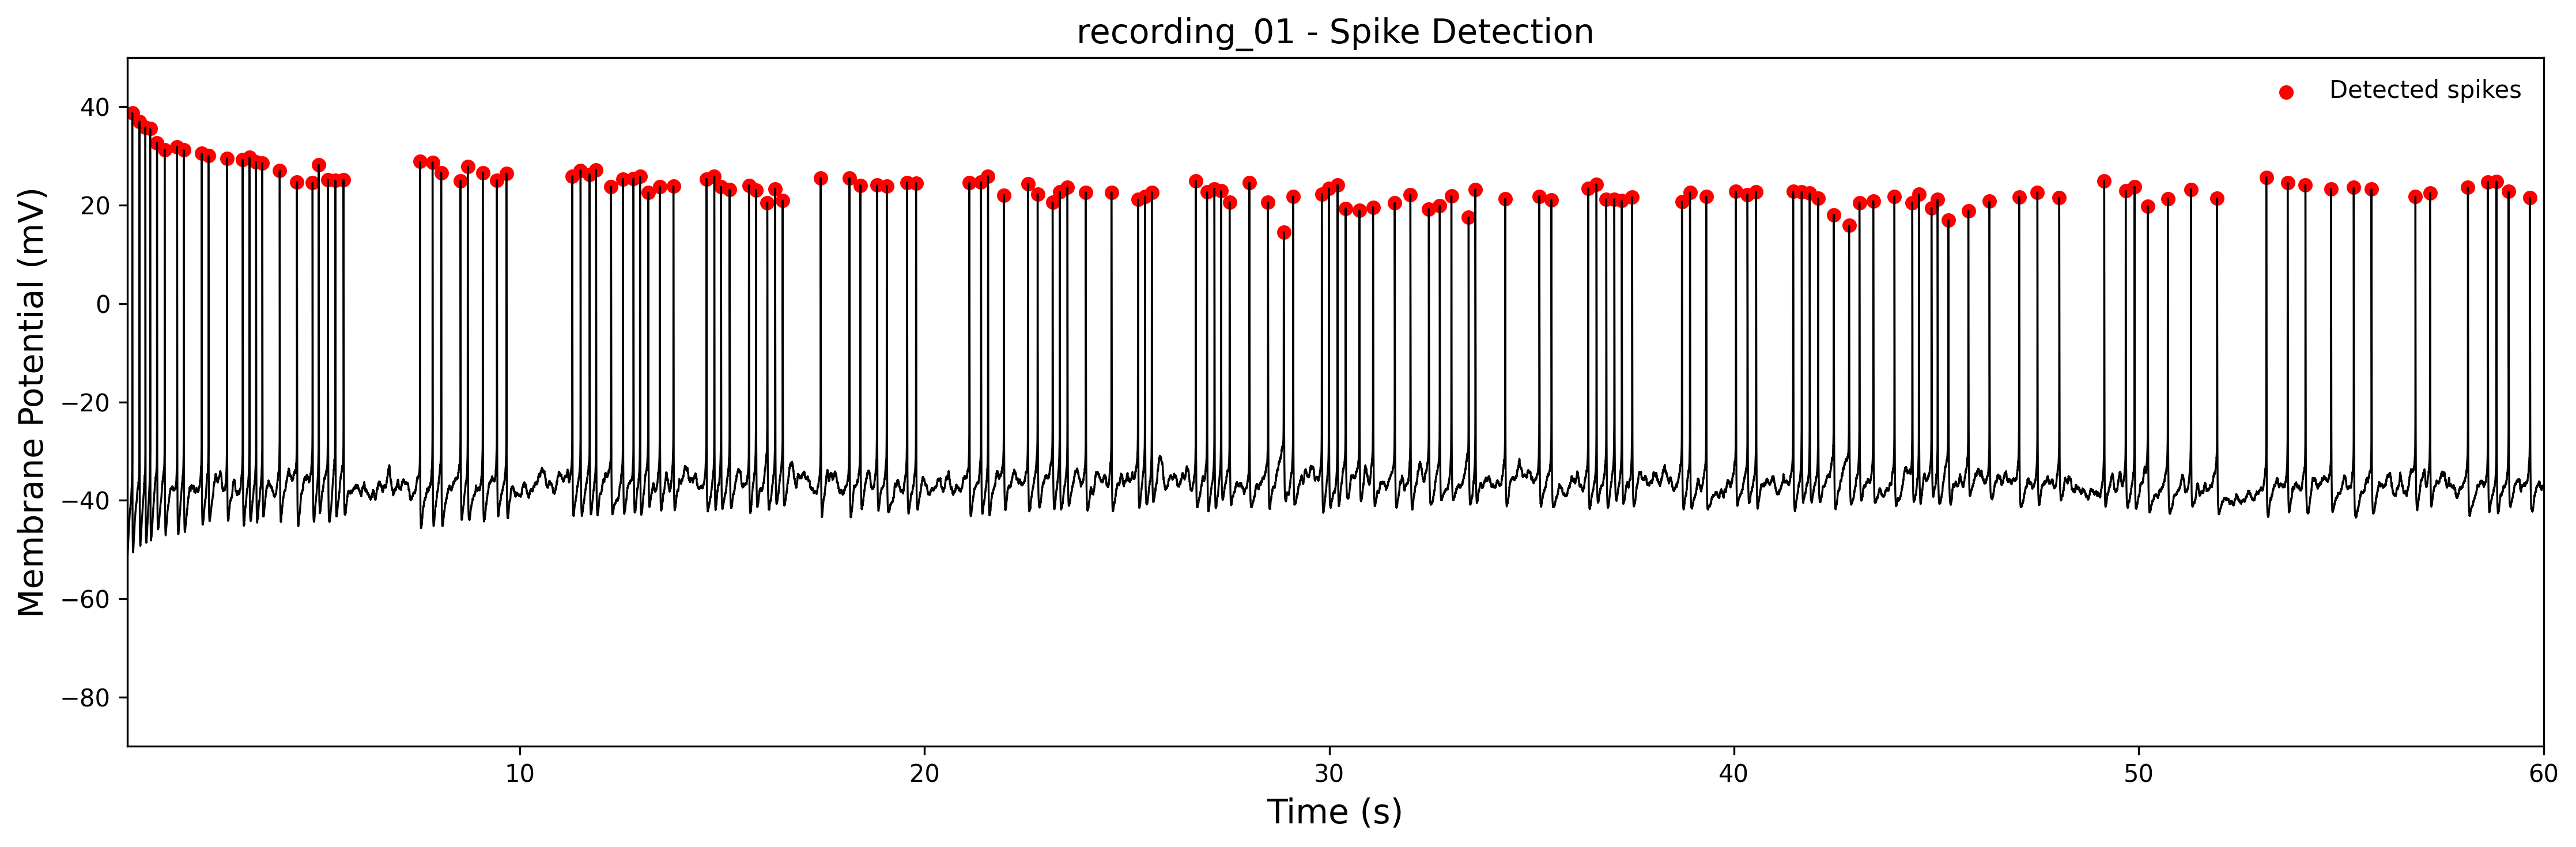

Representative QC results:
Recording: recording_01
Spike count: 147
Spike frequency: 2.462 Hz


In [7]:
# ============================================================
# REPRESENTATIVE QUALITY-CONTROL VISUALIZATION
# ============================================================

# Representative example file.
# Replace this with the name of your own HEKA/PatchMaster ASCII file.
PRIVATE_QC_FILE = "recording_01.asc"

# Public anonymized name displayed in the figure
REPRESENTATIVE_RECORDING_NAME = "recording_01"

qc_file_path = os.path.join(BASE_PATH, PRIVATE_QC_FILE)

qc_results, qc_spike_table = analyze_spike_frequency(
    file_path=qc_file_path,
    recording_name=REPRESENTATIVE_RECORDING_NAME,
    condition_name=CONDITION_NAME,
    start_time_s=START_TIME_S,
    end_time_s=END_TIME_S,
    min_peak_mV=MIN_PEAK_MV,
    min_prominence_mV=MIN_PROMINENCE_MV,
    refractory_period_s=REFRACTORY_PERIOD_S,
    y_min=Y_MIN,
    y_max=Y_MAX,
    save_figure=True
)

print("Representative QC results:")
print(f"Recording: {REPRESENTATIVE_RECORDING_NAME}")
print(f"Spike count: {qc_results['spike_count']}")
print(f"Spike frequency: {qc_results['spike_frequency_Hz']:.3f} Hz")